In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO


In [3]:
with open("Homo_sapiens.GRCh38.dna.chromosome.1.fa", "r") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        print(f"Загружена хромосома: {record.id}")
        print(f"Длина: {len(record.seq)}")
        chromosome_seq = record.seq
        break

sequence = chromosome_seq[10000:20000]
sequence  = str(sequence)


Загружена хромосома: 1
Длина: 248956422


Начинаю сканирование...


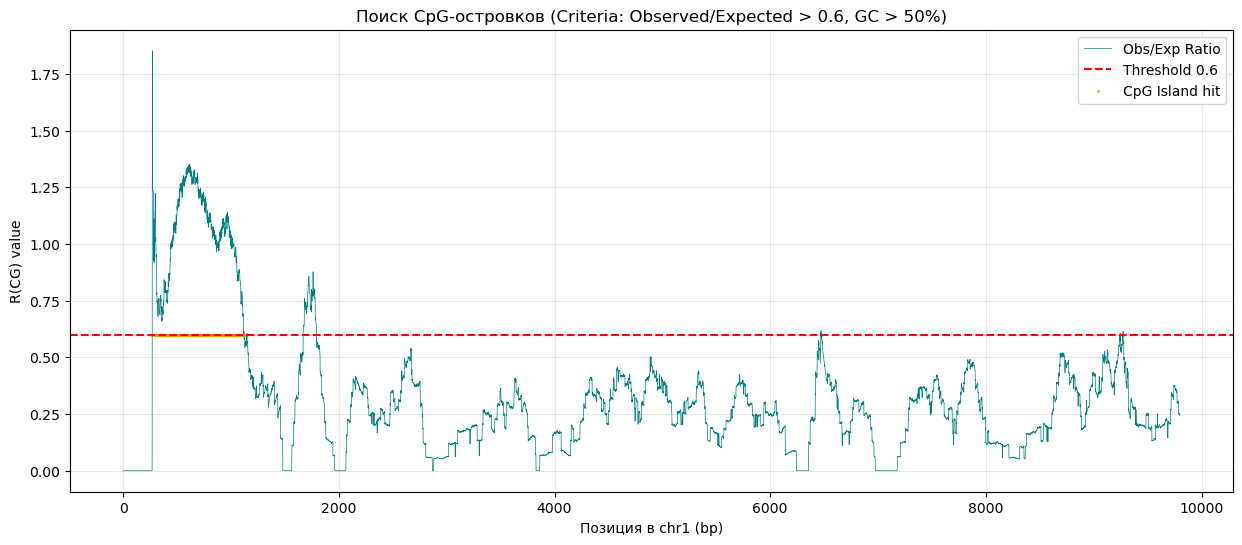

Найдено потенциальных точек в островках: 862
Первые найденные позиции: [270, 271, 272, 273, 274]


In [ ]:
def compute_cpg_ratio(window):
    seq = str(window).upper()
    L = len(seq)
    
    count_c = seq.count('C')
    count_g = seq.count('G')
    
    count_cg = seq.count('CG')
    
    p_c = count_c / L
    p_g = count_g / L
    p_cg = count_cg / L
    
    if p_c * p_g > 0:
        observed_expected_ratio = p_cg / (p_c * p_g)
    else:
        observed_expected_ratio = 0.0
        
    gc_percent = (count_c + count_g) / L * 100
    
    return observed_expected_ratio, gc_percent


dna_slice = sequence[:100000]

window_size = 200
step = 1
ratios = []
islands = []

for i in range(0, len(dna_slice) - window_size, step):
    window = dna_slice[i : i + window_size]
    r_cg, gc_content = compute_cpg_ratio(window)
    ratios.append(r_cg)
    
    if r_cg > 0.6 and gc_content > 50:
        islands.append(i)

plt.figure(figsize=(15, 6))
plt.plot(range(len(ratios)), ratios, color='teal', linewidth=0.5, label='Obs/Exp Ratio')
plt.axhline(y=0.6, color='red', linestyle='--', label='Threshold 0.6')

if islands:
    plt.scatter(islands, [0.6]*len(islands), color='orange', s=1, label='CpG Island hit')

plt.title('Поиск CpG-островков (Criteria: Observed/Expected > 0.6, GC > 50%)')
plt.xlabel('Позиция в chr1 (bp)')
plt.ylabel('R(CG) value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


if islands:
    print(f"Найдено потенциальных точек в островках: {len(islands)}")
    # Для отчета выведем первые 5 координат
    print(f"Первые найденные позиции: {islands[:5]}")